# Closed-memory circuit-level color-code validation

Fully terminated triangular Z memory, rounds = distance, tri_optimal, and the package uniform circuit noise model. Use the `color_code_so` kernel. Selected-color swim uses the ordinary hard selection; the growth convention is uncertified. The default p = 0.003 is an implementation-validation point, not a reproduced threshold point.

In [2]:
%matplotlib inline
from pathlib import Path
import json
import pandas as pd
from color_code_softoutput.circuit_level import CircuitLevelMemoryConfig
from color_code_softoutput.experiments.circuit_level_memory_test import run_experiment
from color_code_softoutput.analysis.circuit_level import CircuitLevelDataset, audit_memory_run, inspect_memory_witnesses
from color_code_softoutput.analysis.swim_distribution import SwimDistanceDistributionPlotter
from color_code_softoutput.analysis.conditional_ler import ConditionalLERAnalyzer
from color_code_softoutput.analysis.postselection import PostSelectionAnalyzer

In [3]:
shots_per_point = 100000
num_workers = 8
batch_size = 500
seed = 2026
verbose = True
config = CircuitLevelMemoryConfig(physical_error_rate=0.001,
    shots_per_point=shots_per_point, num_workers=num_workers,
    batch_size=batch_size, master_seed=seed, verbose=verbose)
config.resolved()

{'distances': (3, 5, 7),
 'physical_error_rate': 0.001,
 'shots_per_point': 100000,
 'batch_size': 500,
 'num_workers': 8,
 'master_seed': 2026,
 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
 'verbose': True}

Loading is the default. Set `RUN_NEW_EXPERIMENT=True` to run the small configured validation grid. Sampling and analysis live in the reusable package.

In [4]:
RUN_NEW_EXPERIMENT = False
existing_run = "/home/quantum_teresheys/workspace/color_code_softoutput/results/20260916_212315_582740_circuit_level_memory_test"
if RUN_NEW_EXPERIMENT:
    run_directory = run_experiment(config).run_directory
else:
    completed = [p.parent for p in sorted(config.output_root.glob("*_circuit_level_memory_test/metadata.json"))
                 if json.loads(p.read_text())["status"] == "sampling_complete"]
    if not existing_run and not completed:
        raise FileNotFoundError("No completed memory run; set RUN_NEW_EXPERIMENT=True")
    run_directory = Path(existing_run) if existing_run else completed[-1]
dataset = CircuitLevelDataset(run_directory)
dataset.available_values()

{'distance': [3, 5, 7], 'physical_error_rate': [0.003]}

In [8]:
pd.DataFrame(dataset.metadata["static_topology"])[["distance", "rounds", "color", "vertices", "mechanisms",
    "half_edges", "class_exists", "balance_passed", "method", "internal_odd_cycle_obstructions"]]

,distance,rounds,color,vertices,mechanisms,half_edges,class_exists,balance_passed,method,internal_odd_cycle_obstructions
0,3,3,r,37,81,43,True,True,two_boundary,0
1,3,3,g,37,81,43,True,True,two_boundary,0
2,3,3,b,37,81,43,True,True,two_boundary,0
3,5,5,r,248,549,196,True,True,two_boundary,0
4,5,5,g,247,549,196,True,True,two_boundary,0
5,5,5,b,249,549,206,True,True,two_boundary,0
6,7,7,r,779,1729,507,True,True,two_boundary,0
7,7,7,g,789,1729,507,True,True,two_boundary,0
8,7,7,b,781,1729,535,True,True,two_boundary,0


In [ ]:
audit_memory_run(dataset, replay=False, check_current_sources=False)
rows = dataset.read()
rows.head()

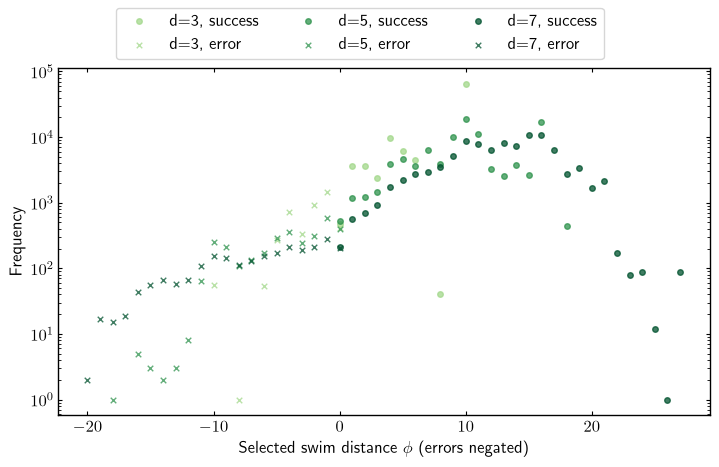

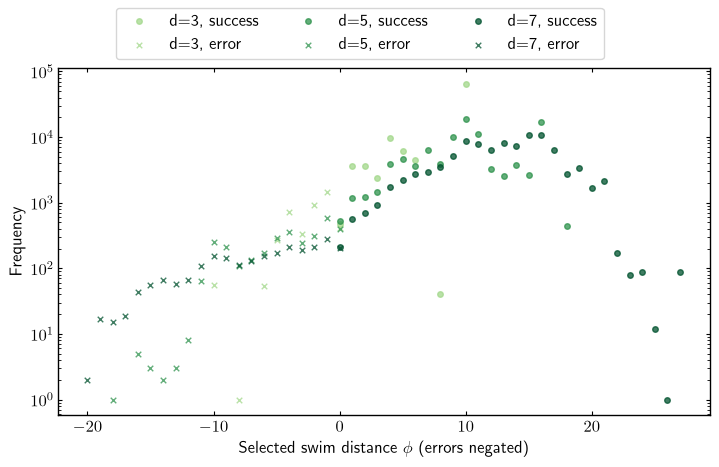

In [9]:
round_digits = 0  # None: current behavior; 0: integers; 1: one decimal place.
selection = dict(distance=dataset.available_values()["distance"],
                 physical_error_rate=dataset.available_values()["physical_error_rate"][0])
figure, counts = SwimDistanceDistributionPlotter().plot(dataset, **selection, signed_logical_errors=True, round_digits=round_digits)
figure

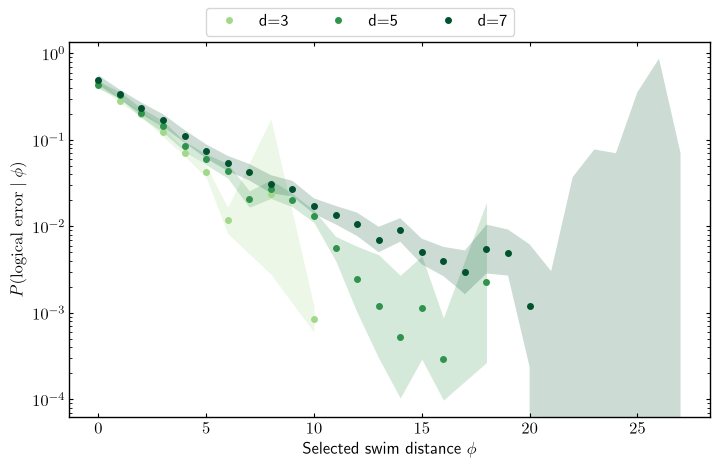

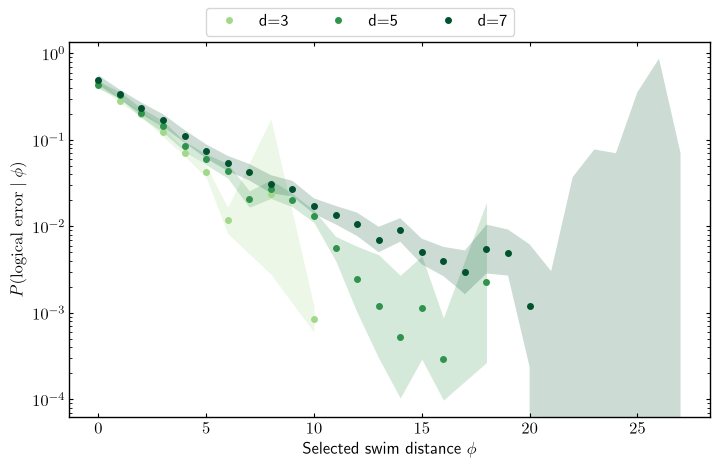

In [5]:
figure, empirical_rates, fits = ConditionalLERAnalyzer().plot(dataset, **selection, overlay_fit=False, round_digits=round_digits)
figure

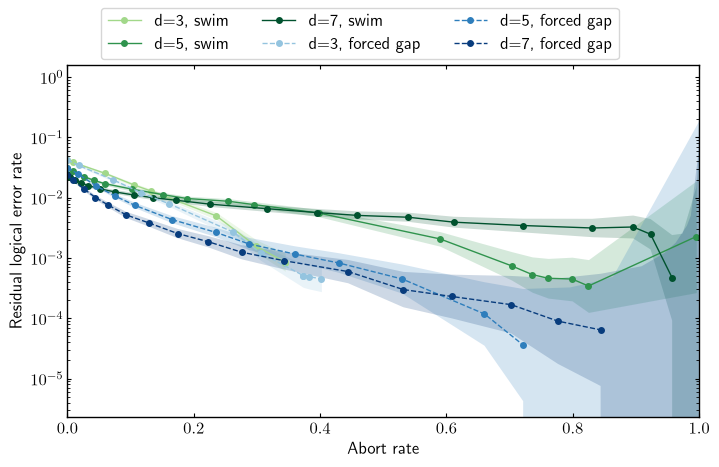

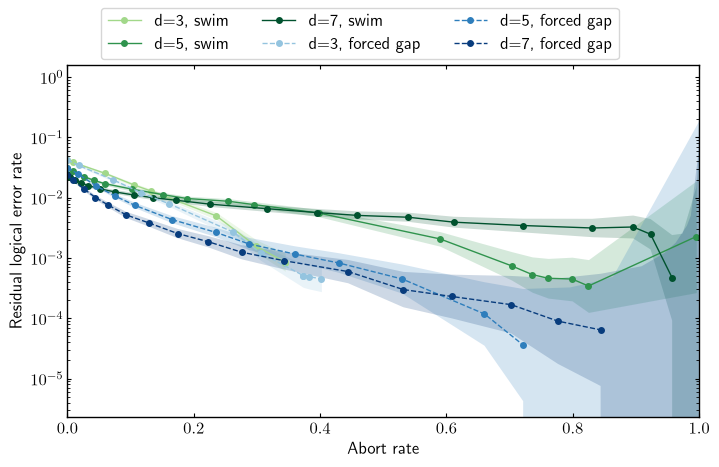

In [6]:
figure, retention = PostSelectionAnalyzer().plot(dataset, **selection, include_forced_gap=True, round_digits=round_digits)
figure

In [11]:
examples = inspect_memory_witnesses(dataset, max_shots=3)
examples

[{'config_id': 'memory_uniform_d3_t3_p0.003',
  'shot_index': 5309,
  'ordinary_failure': True,
  'disagreement': True,
  'selected_color': 'g',
  'branches': {'r': {'phi': 4.049545511894192,
    'column_ids': (8, 21, 39, 40),
    'stable_ids': ('9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:r:column:64',
     '9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:r:column:62',
     '9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:r:column:74',
     '9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:r:column:73'),
    'cost': 4.049545511894192},
   'g': {'phi': 2.6121975461734026,
    'column_ids': (21, 29, 69),
    'stable_ids': ('9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:g:column:62',
     '9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:g:column:76',
     '9f724ef15b0fcbf60359b70214dac85d450c6ef48919a9702ee5ccdeee3e3042:g:column:63'),
    'cost': 2.6121975461734026},
   'b': {'phi':

In [12]:
dataset.metadata["hard_output_invariance"]

{'checked_shots': 300000,
 'mismatches': 0,
 'scope': 'prediction, ordinary weight, selected color, correction and failure label'}

All per-color values and method/status flags remain in Parquet. Swim uses ordinary failure labels; forced gap aliases the existing comparative logical gap and uses comparative failure labels. Optional round_digits rounds actual scores before grouping, fitting, or thresholding; None preserves the previous behavior. Post-selection retains whole ties in the chosen score representation. Raw Parquet values remain unchanged. No posterior calibration, certified representative bound, family-wide balance theorem, threshold sweep, or open temporal/sliding-window decoding is included.

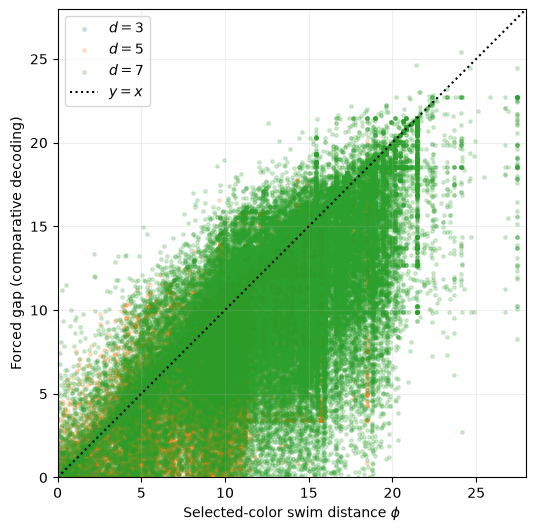

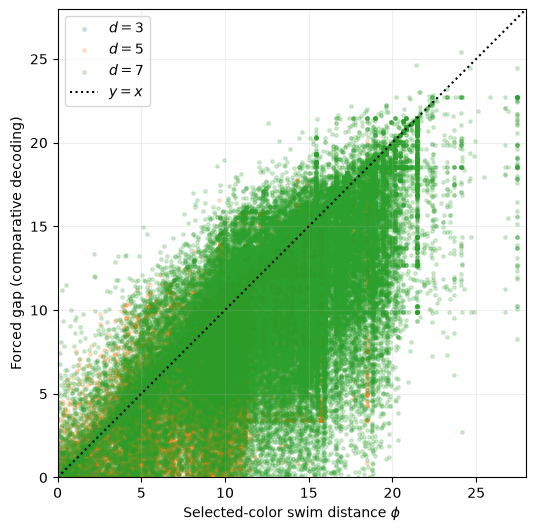

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from color_code_softoutput.analysis.circuit_level import CircuitLevelDataset

# This cell can be run on its own: reuse the notebook dataset when available,
# otherwise load the same saved run configured above.
scatter_dataset = globals().get("dataset")
if scatter_dataset is None:
    scatter_run = Path(
        "/home/quantum_teresheys/workspace/color_code_softoutput/results/"
        "20260916_212315_582740_circuit_level_memory_test"
    )
    scatter_dataset = CircuitLevelDataset(scatter_run)
scatter_rows = scatter_dataset.read()

# Reconstruct phi explicitly from the branch chosen by ordinary decoding.
selected_phi = pd.Series(index=scatter_rows.index, dtype=float, name="selected_phi")
for color in ("r", "g", "b"):
    mask = scatter_rows["ordinary_selected_color"].eq(color)
    selected_phi.loc[mask] = scatter_rows.loc[mask, f"swim_distance_{color}"]
pd.testing.assert_series_equal(
    selected_phi, scatter_rows["selected_swim_distance"].rename("selected_phi")
)

fig, ax = plt.subplots(figsize=(6.4, 5.2), constrained_layout=True)
plot_rows = scatter_rows.assign(selected_phi=selected_phi)
for distance, group in plot_rows.groupby("distance", sort=True):
    ax.scatter(group["selected_phi"], group["forced_gap"], s=6, alpha=0.20,
               label=fr"$d={distance}$", rasterized=True)
limit = 1.02 * max(selected_phi.max(), scatter_rows["forced_gap"].max())
ax.plot([0, limit], [0, limit], color="black", linestyle=":", linewidth=1.5,
        label=r"$y=x$")
ax.set(xlim=(0, limit), ylim=(0, limit),
       xlabel=r"Selected-color swim distance $\phi$",
       ylabel="Forced gap (comparative decoding)")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend()
fig

In [ ]:
from color_code_softoutput.analysis.circuit_level import comparative_correction_color_summary

# The first call deterministically replays saved batch seeds and writes the six
# class/color candidate weights to comparative_candidates/*.parquet. Later calls
# only validate and read those sidecars; the original shot Parquet is unchanged.
comparative_color_summary = comparative_correction_color_summary(
    dataset, generate=True, num_workers=dataset.metadata["resolved_config"]["num_workers"]
)
display(comparative_color_summary.style.format({
    "same_color_fraction": "{:.2%}",
    "different_color_fraction": "{:.2%}",
}))